In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [16]:
df = pd.read_csv("../data/processed/processed_data.csv")
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nHealth risk distribution:")
print(df['health_risk'].value_counts())

Shape: (21840, 27)

Columns: ['timestamp', 'city', 'latitude', 'longitude', 'pm10', 'pm2_5', 'carbon_monoxide', 'nitrogen_dioxide', 'sulphur_dioxide', 'ozone', 'dust', 'temperature', 'humidity', 'precipitation', 'wind_speed', 'wind_direction', 'pressure', 'date', 'hour', 'day_of_week', 'month', 'month_name', 'year', 'is_weekend', 'season', 'aqi_category', 'health_risk']

Health risk distribution:
health_risk
Unhealthy    12965
Moderate      4861
Hazardous     3255
Good           759
Name: count, dtype: int64


In [17]:
drop_cols = ['timestamp', 'date', 'month_name', 'aqi_category', 
             'health_risk', 'city', 'season', 'latitude', 'longitude',
             'day_of_week','pm2_5']

X = df.drop(columns=drop_cols)
y = df['health_risk']

X['is_weekend'] = X['is_weekend'].astype(int)

print("Features used for modeling:")
print(X.columns.tolist())
print("\nFeature matrix shape:", X.shape)
print("\nTarget distribution:")
print(y.value_counts())

Features used for modeling:
['pm10', 'carbon_monoxide', 'nitrogen_dioxide', 'sulphur_dioxide', 'ozone', 'dust', 'temperature', 'humidity', 'precipitation', 'wind_speed', 'wind_direction', 'pressure', 'hour', 'month', 'year', 'is_weekend']

Feature matrix shape: (21840, 16)

Target distribution:
health_risk
Unhealthy    12965
Moderate      4861
Hazardous     3255
Good           759
Name: count, dtype: int64


In [18]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

os.makedirs("../models", exist_ok=True)
joblib.dump(scaler, "../models/scaler.pkl")
print("Scaler saved.")

Training set size: (17472, 16)
Test set size: (4368, 16)
Scaler saved.


In [19]:
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    'KNN': KNeighborsClassifier(n_neighbors=5)
}

results = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    results[name] = {'Accuracy': round(acc, 4), 'F1 Score': round(f1, 4)}
    print(f"{name} — Accuracy: {acc:.4f}, F1: {f1:.4f}")

print("\nDone training all models.")

Training Decision Tree...
Decision Tree — Accuracy: 0.9799, F1: 0.9798
Training Random Forest...
Random Forest — Accuracy: 0.9826, F1: 0.9826
Training KNN...
KNN — Accuracy: 0.9029, F1: 0.9024

Done training all models.


In [20]:
results_df = pd.DataFrame(results).T.reset_index()
results_df.columns = ['Model', 'Accuracy', 'F1 Score']
print(results_df)

results_df.to_csv("../models/model_comparison.csv", index=False)
print("\nModel comparison saved.")

best_model = models['Random Forest']
joblib.dump(best_model, "../models/random_forest_model.pkl")
print("Random Forest model saved.")

           Model  Accuracy  F1 Score
0  Decision Tree    0.9799    0.9798
1  Random Forest    0.9826    0.9826
2            KNN    0.9029    0.9024

Model comparison saved.
Random Forest model saved.


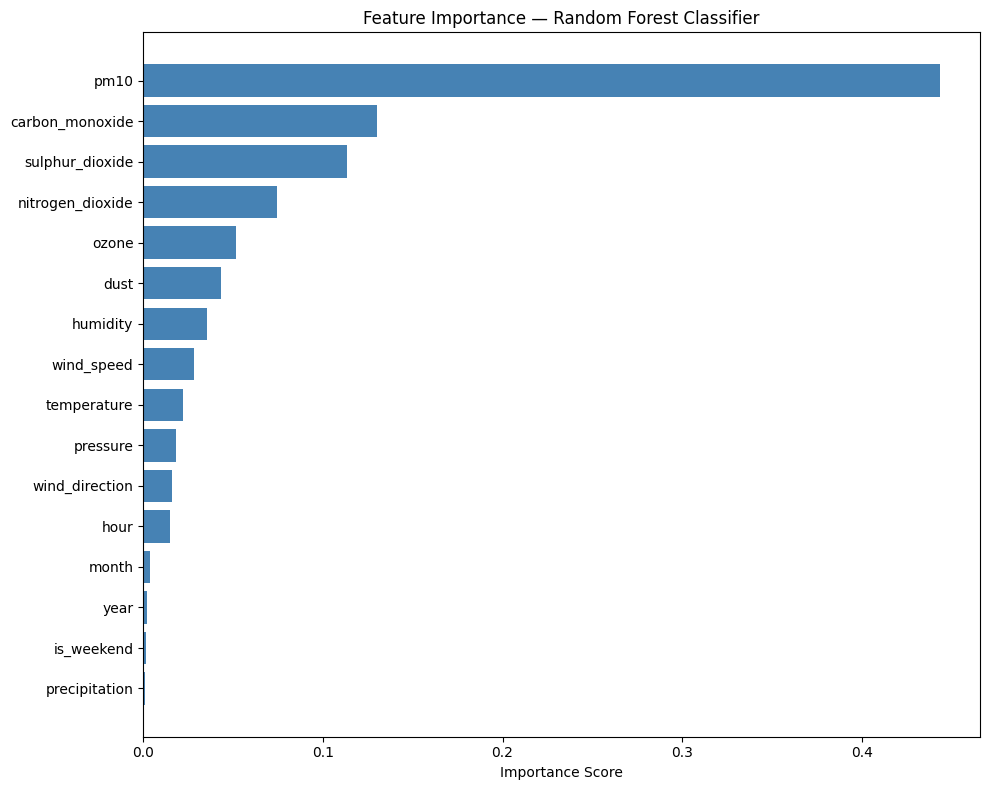

Feature importance chart saved.


In [22]:
rf_model = models['Random Forest']

feature_names = list(X.columns)

importances = rf_model.feature_importances_
feat_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(feat_df['Feature'], feat_df['Importance'], color='steelblue')
plt.title("Feature Importance — Random Forest Classifier")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.savefig("../models/feature_importance.png")
plt.show()
print("Feature importance chart saved.")

City Clusters:
             city       pm2_5     pollution_level
0      Faisalabad  155.736310  Moderate Pollution
1       Islamabad   56.125504  Moderate Pollution
2         Karachi   37.708974       Low Pollution
3          Lahore  126.761264      High Pollution
4          Multan  136.831777  Moderate Pollution
5        Peshawar   53.729579  Moderate Pollution
6          Quetta   19.104991       Low Pollution
7  Rahim Yar Khan   72.364927       Low Pollution
8      Rawalpindi   56.125504  Moderate Pollution
9         Sialkot  115.192582  Moderate Pollution

City clusters saved.


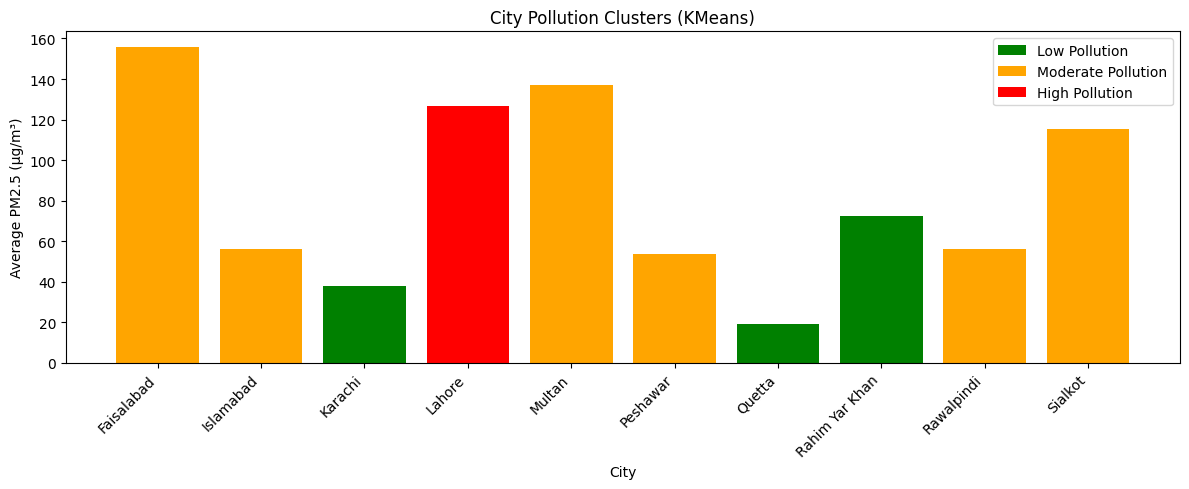

Cluster chart saved.


In [23]:
city_profile = df.groupby('city')[['pm2_5', 'pm10', 'carbon_monoxide', 
                                    'nitrogen_dioxide', 'dust']].mean()

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
city_profile['cluster'] = kmeans.fit_predict(city_profile)

cluster_means = city_profile.groupby('cluster')['pm2_5'].mean().sort_values()
cluster_labels = {cluster_means.index[0]: 'Low Pollution',
                  cluster_means.index[1]: 'Moderate Pollution', 
                  cluster_means.index[2]: 'High Pollution'}

city_profile['pollution_level'] = city_profile['cluster'].map(cluster_labels)
city_profile = city_profile.reset_index()

print("City Clusters:")
print(city_profile[['city', 'pm2_5', 'pollution_level']])

city_profile.to_csv("../models/city_clusters.csv", index=False)
print("\nCity clusters saved.")

plt.figure(figsize=(12, 5))
colors = {'Low Pollution': 'green', 'Moderate Pollution': 'orange', 'High Pollution': 'red'}
bar_colors = [colors[level] for level in city_profile['pollution_level']]
plt.bar(city_profile['city'], city_profile['pm2_5'], color=bar_colors)
plt.title("City Pollution Clusters (KMeans)")
plt.xlabel("City")
plt.ylabel("Average PM2.5 (μg/m³)")
plt.xticks(rotation=45, ha='right')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='green', label='Low Pollution'),
                   Patch(facecolor='orange', label='Moderate Pollution'),
                   Patch(facecolor='red', label='High Pollution')]
plt.legend(handles=legend_elements)
plt.tight_layout()
plt.savefig("../models/city_clusters.png")
plt.show()
print("Cluster chart saved.")

In [24]:
df_reg = df.copy()
df_reg = df_reg.sort_values(['city', 'timestamp'])
df_reg['pm2_5_lag1'] = df_reg.groupby('city')['pm2_5'].shift(1)
df_reg['pm2_5_lag3'] = df_reg.groupby('city')['pm2_5'].shift(3)
df_reg['pm2_5_rolling7'] = df_reg.groupby('city')['pm2_5'].transform(
    lambda x: x.rolling(7, min_periods=1).mean()
)
df_reg = df_reg.dropna()

reg_features = ['pm2_5_lag1', 'pm2_5_lag3', 'pm2_5_rolling7', 
                'hour', 'month', 'humidity', 'wind_speed', 'temperature']

X_reg = df_reg[reg_features]
y_reg = df_reg['pm2_5']

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

reg_model = RandomForestRegressor(n_estimators=100, random_state=42)
reg_model.fit(X_reg_train, y_reg_train)
y_reg_pred = reg_model.predict(X_reg_test)

rmse = np.sqrt(mean_squared_error(y_reg_test, y_reg_pred))
mae = mean_absolute_error(y_reg_test, y_reg_pred)
print(f"Regression Model Results:")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")

joblib.dump(reg_model, "../models/regression_model.pkl")
print("Regression model saved.")

Regression Model Results:
RMSE: 8.55
MAE: 4.58
Regression model saved.


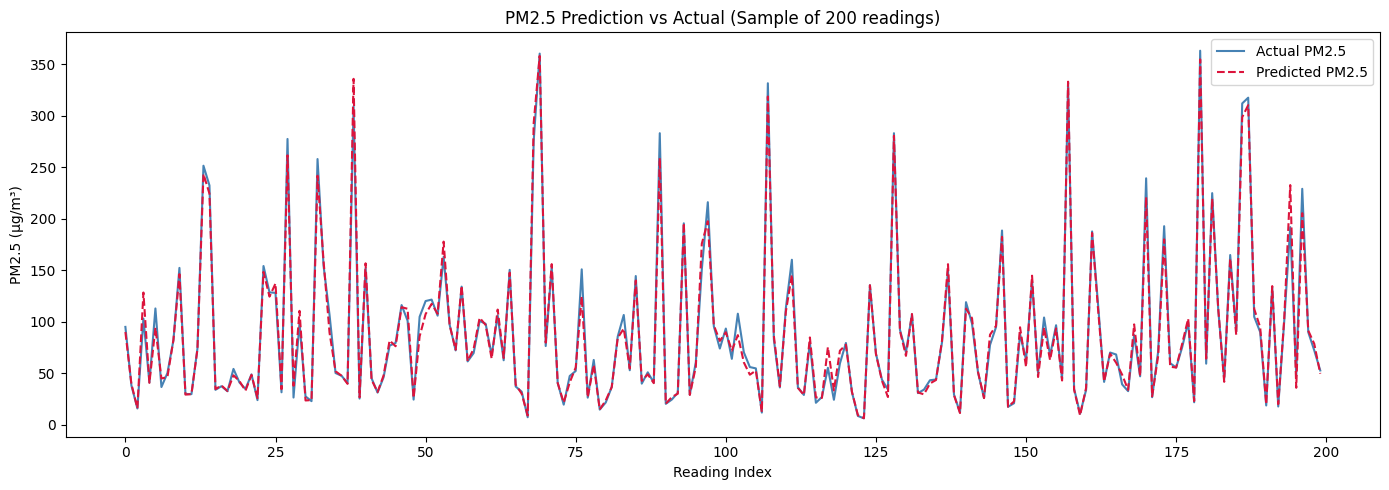

Prediction chart saved.


In [25]:
sample_size = 200
y_sample = y_reg_test[:sample_size].values
y_pred_sample = y_reg_pred[:sample_size]

plt.figure(figsize=(14, 5))
plt.plot(y_sample, label='Actual PM2.5', color='steelblue', linewidth=1.5)
plt.plot(y_pred_sample, label='Predicted PM2.5', color='crimson', 
         linewidth=1.5, linestyle='--')
plt.title("PM2.5 Prediction vs Actual (Sample of 200 readings)")
plt.xlabel("Reading Index")
plt.ylabel("PM2.5 (μg/m³)")
plt.legend()
plt.tight_layout()
plt.savefig("../models/prediction_vs_actual.png")
plt.show()
print("Prediction chart saved.")